# 🔤 TOKENIZAÇÃO - Como LLMs Entendem Texto Humano

**Objetivo:** Dominar tokenização, embeddings e preparação de texto para LLMs

## 📚 Índice

1. [Introdução: Por que Tokenizar?](#1-introdução-por-que-tokenizar)
2. [Evolução da Tokenização](#2-evolução-da-tokenização)
3. [Algoritmos Modernos](#3-algoritmos-modernos)
4. [Comparação Prática](#4-comparação-prática)
5. [Tokenização em Português](#5-tokenização-em-português)
6. [Tokenização Jurídica](#6-tokenização-jurídica)
7. [Exercícios Práticos](#7-exercícios-práticos)
8. [Otimização para GPU 2GB](#8-otimização-para-gpu-2gb)


## 🎯 Objetivos de Aprendizado

Ao final deste notebook, você será capaz de:
✅ Entender diferentes algoritmos de tokenização  
✅ Escolher o tokenizador certo para cada tarefa  
✅ Tokenizar textos em português e jurídicos  
✅ Criar vocabulários personalizados  
✅ Otimizar tokenização para sua GPU

## ⚙️ Configuração do Ambiente

In [1]:
# Importações essenciais
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer
from collections import Counter, defaultdict
import re
from IPython.display import display, Markdown, HTML
import warnings
warnings.filterwarnings('ignore')

# Configuração de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12

print("✅ Bibliotecas importadas com sucesso!")
print(f"📊 PyTorch: {torch.__version__}")
print(f"🎮 GPU disponível: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"🖥️  GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 Memória GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✅ Bibliotecas importadas com sucesso!
📊 PyTorch: 2.0.1+cpu
🎮 GPU disponível: False


## 1. Introdução: Por que Tokenizar?

### O Problema Fundamental
Computadores processam números, não texto. Quando você digita "Olá", o computador vê:

    01001111 01101100 11000011 10101001 (UTF-8)

**Tokenização é o processo de converter texto em números** que modelos podem entender.

### Analogia: Aprender um Novo Idioma
Pense em como você aprende inglês:
1. Aprende palavras individuais (tokens)
2. Aprende como combiná-las
3. Aprende exceções e contextos

LLMs fazem algo similar, mas em escala massiva!

In [2]:
# Demonstração visual do problema
def visualizar_texto_como_bytes(texto):
    """Mostra como o computador vê texto"""
    print(f"Texto: '{texto}'")
    print("Bytes (UTF-8):", end=" ")
    for byte in texto.encode('utf-8'):
        print(f"{byte:08b}", end=" ")
    print("\n")
    
# Exemplos
visualizar_texto_como_bytes("Olá")
visualizar_texto_como_bytes("AI")
visualizar_texto_como_bytes("😊")

Texto: 'Olá'
Bytes (UTF-8): 01001111 01101100 11000011 10100001 

Texto: 'AI'
Bytes (UTF-8): 01000001 01001001 

Texto: '😊'
Bytes (UTF-8): 11110000 10011111 10011000 10001010 



### O Trade-off da Tokenização

| Método        | Vocabulário | Sequências   | Palavras Novas       | Exemplo           |     
|---------------|-------------|--00----------|-------000000---------|--0000000000-------|     
| **Caractere** | ~256        | Muito longas | 👍 Sempre funciona   | O-l-á- -M-u-n-d-o |     
| **Palavra**   | 50k-500k    | Curtas       | 👎 Não conhece novas | Olá-Mundo         |       
| **Subword**   | 30k-100k    | Média        | 👍 Pode decompor     | Ol-á-Mund-o       |     

**Subword é o padrão atual** porque equilibra todos os fatores.

In [3]:
# Demonstração dos três métodos
texto_exemplo = "Aprender tokenização é fundamental para LLMs."

print("📝 Exemplo: 'Aprender tokenização é fundamental para LLMs.'")
print("\n1. Tokenização por caractere:")
print("   ", list(texto_exemplo))

print("\n2. Tokenização por palavra (simplificada):")
print("   ", texto_exemplo.split())

print("\n3. Tokenização subword (GPT-2 style):")
# Simulação simplificada
tokens_simulados = ["Apre", "nder", " token", "ização", " é", " fundamental", " para", " LL", "Ms", "."]
print("   ", tokens_simulados)

📝 Exemplo: 'Aprender tokenização é fundamental para LLMs.'

1. Tokenização por caractere:
    ['A', 'p', 'r', 'e', 'n', 'd', 'e', 'r', ' ', 't', 'o', 'k', 'e', 'n', 'i', 'z', 'a', 'ç', 'ã', 'o', ' ', 'é', ' ', 'f', 'u', 'n', 'd', 'a', 'm', 'e', 'n', 't', 'a', 'l', ' ', 'p', 'a', 'r', 'a', ' ', 'L', 'L', 'M', 's', '.']

2. Tokenização por palavra (simplificada):
    ['Aprender', 'tokenização', 'é', 'fundamental', 'para', 'LLMs.']

3. Tokenização subword (GPT-2 style):
    ['Apre', 'nder', ' token', 'ização', ' é', ' fundamental', ' para', ' LL', 'Ms', '.']


## 2. Evolução da Tokenização

### Linha do Tempo
2013-2016: Word-based → Vocabulários enormes  
2017: WordPiece (BERT) → Melhor para tarefas específicas  
2018: BPE (GPT) → Excelente para geração  
2019: SentencePiece → Independente de linguagem  
2020+: Tokenizadores otimizados → Mais eficientes  

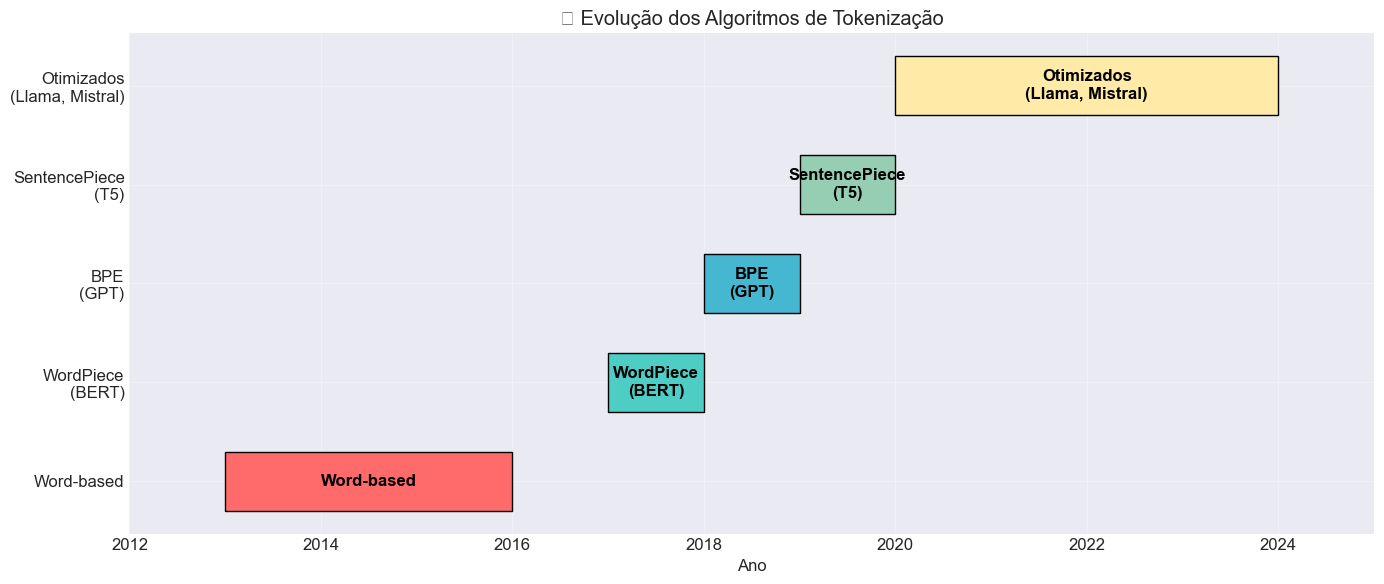

In [4]:
# Timeline interativa
fig, ax = plt.subplots(figsize=(14, 6))

timeline_data = [
    ("Word-based", 2013, 2016, "#FF6B6B"),
    ("WordPiece\n(BERT)", 2017, 2018, "#4ECDC4"),
    ("BPE\n(GPT)", 2018, 2019, "#45B7D1"),
    ("SentencePiece\n(T5)", 2019, 2020, "#96CEB4"),
    ("Otimizados\n(Llama, Mistral)", 2020, 2024, "#FFEAA7")
]

for name, start, end, color in timeline_data:
    ax.barh(name, end-start, left=start, height=0.6, color=color, edgecolor='black')
    ax.text(start + (end-start)/2, name, name, ha='center', va='center', 
            fontweight='bold', color='black')

ax.set_xlabel('Ano')
ax.set_title('📅 Evolução dos Algoritmos de Tokenização')
ax.set_xlim(2012, 2025)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Algoritmos Modernos

### 3.1 Byte-Pair Encoding (BPE) - GPT Series
- **Funcionamento:** Começa com caracteres, funde pares frequentes
- **Vantagens:** Ótimo para geração, eficiente
- **Uso:** GPT-2, GPT-3, GPT-4, LLaMA

### 3.2 WordPiece - BERT Series  
- **Funcionamento:** Similar ao BPE, mas com critério diferente
- **Vantagens:** Melhor para tarefas de classificação
- **Uso:** BERT, DistilBERT, LegalBERT

### 3.3 SentencePiece - T5, ALBERT
- **Funcionamento:** Trata texto como sequência raw de bytes
- **Vantagens:** Independente de linguagem, sem pré-processamento
- **Uso:** T5, ALBERT, alguns modelos multilíngues

In [5]:
# Implementação didática do BPE (simplificada)
class BPETokenizerDemo:
    def __init__(self):
        self.vocab = {}
        self.merges = {}
    
    def get_stats(self, words):
        """Conta pares de símbolos adjacentes"""
        pairs = Counter()
        for word, freq in words.items():
            symbols = word.split()
            for i in range(len(symbols)-1):
                pairs[symbols[i], symbols[i+1]] += freq
        return pairs
    
    def merge_vocab(self, pair, words):
        """Merge o par mais frequente"""
        bigram = ' '.join(pair)
        replacement = ''.join(pair)
        
        new_words = {}
        for word, freq in words.items():
            new_word = word.replace(bigram, replacement)
            new_words[new_word] = freq
        
        return new_words
    
    def train(self, corpus, num_merges=20):
        """Treina tokenizador BPE"""
        # Inicializa com caracteres
        words = {}
        for text in corpus:
            # Adiciona marcador de fim de palavra
            word = ' '.join(list(text)) + ' </w>'
            words[word] = words.get(word, 0) + 1
        
        # Aplicar merges
        for i in range(num_merges):
            pairs = self.get_stats(words)
            if not pairs:
                break
            
            best_pair = max(pairs, key=pairs.get)
            words = self.merge_vocab(best_pair, words)
            self.merges[best_pair] = i
        
        # Cria vocabulário final
        self.vocab = set()
        for word in words.keys():
            for token in word.split():
                self.vocab.add(token)
        
        return self.vocab

# Demonstração
print("🧪 Demonstração do BPE (simplificada)")
corpus = ["aprender", "aprendizado", "aprendiz", "token", "tokenização", "tokenizar"]
bpe_demo = BPETokenizerDemo()
vocab = bpe_demo.train(corpus, num_merges=10)

print(f"Corpus: {corpus}")
print(f"Merges realizados: {len(bpe_demo.merges)}")
print(f"Vocabulário final (primeiros 10): {list(vocab)[:10]}")

🧪 Demonstração do BPE (simplificada)
Corpus: ['aprender', 'aprendizado', 'aprendiz', 'token', 'tokenização', 'tokenizar']
Merges realizados: 10
Vocabulário final (primeiros 10): ['</w>', 'iz', 'ç', 'ã', 'e', 'o', 'token', 'iza', 'r', 'aprend']


## 4. Comparação Prática

Vamos comparar tokenizadores reais em diferentes tipos de texto.


📝 TEXTO: Simples
Conteúdo: A inteligência artificial transforma o mundo.


tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

,Modelo,Número de Tokens,Vocabulário
0,BERT (PT),7,29794
1,BERT (EN),10,30522
2,GPT-2,13,50257
3,T5,16,32100
4,LLaMA Tokenizer,10,32000
5,Legal-BERT,11,30522


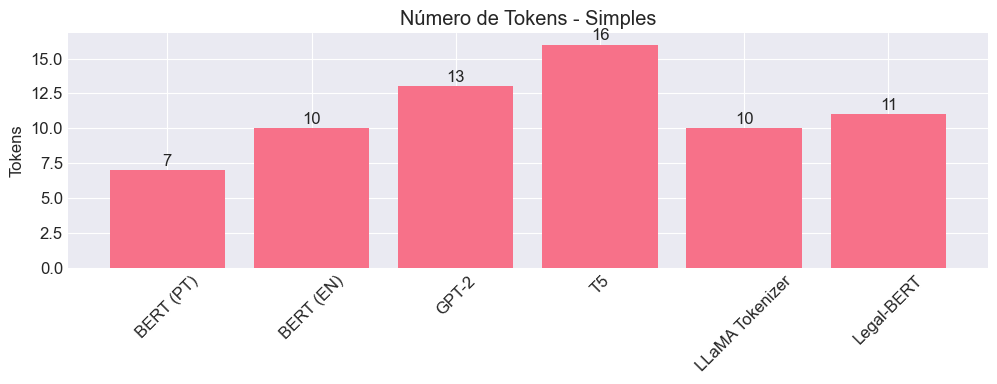


🔍 Tokens BERT Português:
   ['A', 'inteligência', 'artificial', 'transforma', 'o', 'mundo', '.']

📝 TEXTO: Técnico
Conteúdo: Backpropagation é usado no treinamento de redes neurais.


,Modelo,Número de Tokens,Vocabulário
0,BERT (PT),14,29794
1,BERT (EN),18,30522
2,GPT-2,18,50257
3,T5,21,32100
4,LLaMA Tokenizer,17,32000
5,Legal-BERT,18,30522


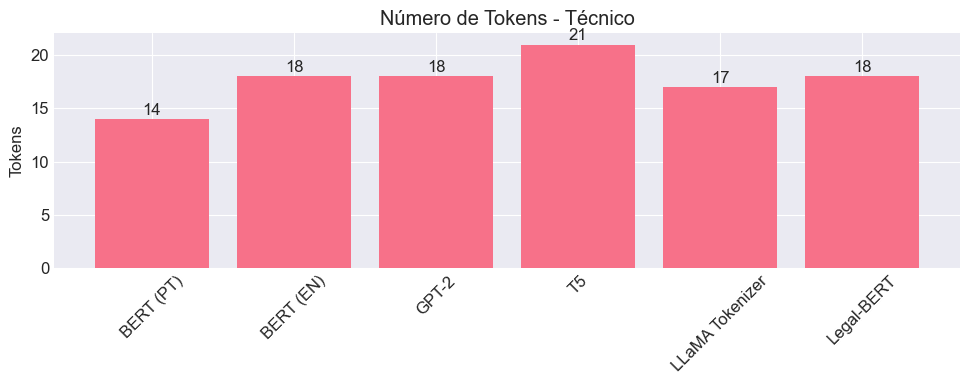


🔍 Tokens BERT Português:
   ['Back', '##pro', '##pa', '##gat', '##ion', 'é', 'usado', 'no', 'treinamento', 'de', 'redes', 'neur', '##ais', '.']

📝 TEXTO: Jurídico
Conteúdo: Art. 5º, § 3º, inciso IV da Constituição Federal.


,Modelo,Número de Tokens,Vocabulário
0,BERT (PT),14,29794
1,BERT (EN),20,30522
2,GPT-2,20,50257
3,T5,23,32100
4,LLaMA Tokenizer,22,32000
5,Legal-BERT,16,30522


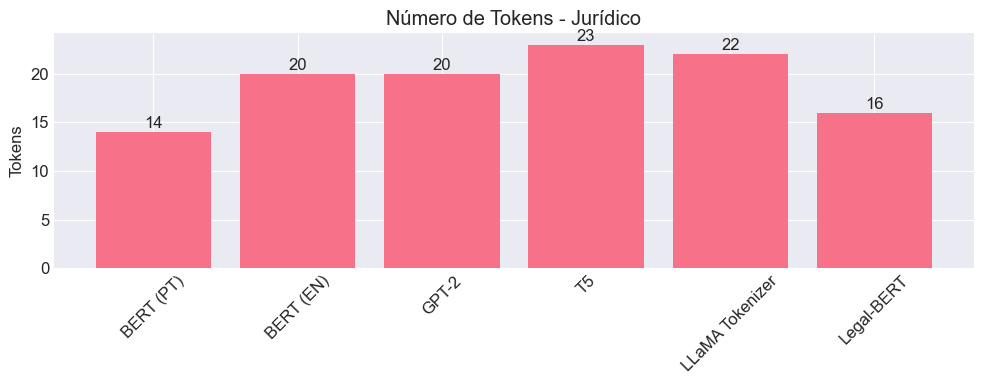


🔍 Tokens BERT Português:
   ['Art', '.', '[UNK]', ',', '§', '[UNK]', ',', 'inc', '##iso', 'IV', 'da', 'Constituição', 'Federal', '.']

📝 TEXTO: Código
Conteúdo: def train_model(X, y, epochs=10): return model.fit(X, y)


,Modelo,Número de Tokens,Vocabulário
0,BERT (PT),29,29794
1,BERT (EN),24,30522
2,GPT-2,23,50257
3,T5,29,32100
4,LLaMA Tokenizer,24,32000
5,Legal-BERT,25,30522


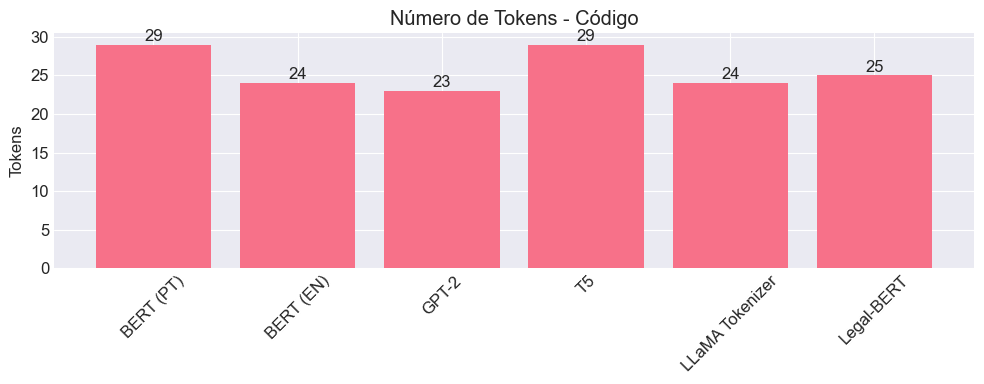


🔍 Tokens BERT Português:
   ['def', 'tra', '##in', '_', 'model', '(', 'X', ',', 'y', ',', 'ep', '##och', '##s', '=', '10', ')', ':', 'ret', '##ur', '##n', 'model', '.', 'fi', '##t', '(', 'X', ',', 'y', ')']

📝 TEXTO: Emoji
Conteúdo: LLMs são incríveis! 🚀😊


,Modelo,Número de Tokens,Vocabulário
0,BERT (PT),9,29794
1,BERT (EN),9,30522
2,GPT-2,15,50257
3,T5,16,32100
4,LLaMA Tokenizer,17,32000
5,Legal-BERT,11,30522


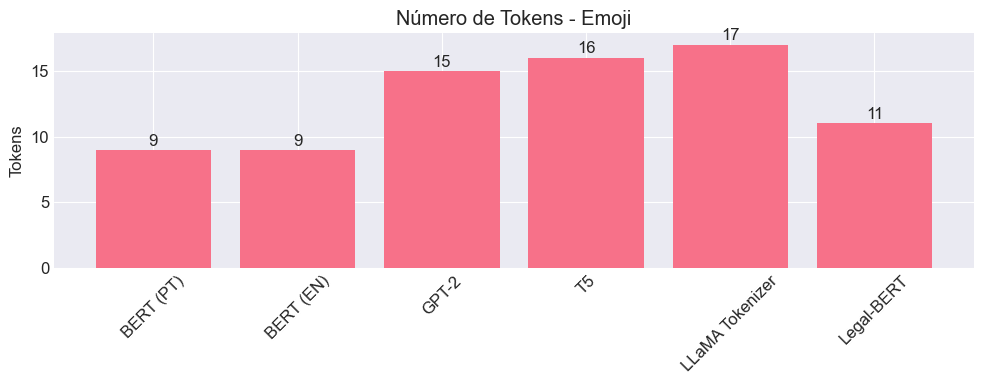


🔍 Tokens BERT Português:
   ['L', '##L', '##M', '##s', 'são', 'inc', '##ríveis', '!', '[UNK]']


In [6]:
def comparar_tokenizadores(texto, modelos):
    """Compara diferentes tokenizadores no mesmo texto"""
    resultados = []
    
    for nome_modelo, modelo_hf in modelos.items():
        try:
            tokenizer = AutoTokenizer.from_pretrained(modelo_hf)
            tokens = tokenizer.tokenize(texto)
            token_ids = tokenizer.encode(texto)
            
            resultados.append({
                'Modelo': nome_modelo,
                'Tokenizador': modelo_hf,
                'Tokens': tokens,
                'Token IDs': token_ids[:10],  # Primeiros 10 apenas
                'Número de Tokens': len(tokens),
                'Comprimento IDs': len(token_ids),
                'Vocabulário': tokenizer.vocab_size
            })
        except Exception as e:
            print(f"⚠️  Erro com {nome_modelo}: {e}")
    
    return pd.DataFrame(resultados)

# Textos de teste
textos_teste = {
    "Simples": "A inteligência artificial transforma o mundo.",
    "Técnico": "Backpropagation é usado no treinamento de redes neurais.",
    "Jurídico": "Art. 5º, § 3º, inciso IV da Constituição Federal.",
    "Código": "def train_model(X, y, epochs=10): return model.fit(X, y)",
    "Emoji": "LLMs são incríveis! 🚀😊"
}

# Modelos para comparar
modelos_comparacao = {
    "BERT (PT)": "neuralmind/bert-base-portuguese-cased",
    "BERT (EN)": "bert-base-uncased",
    "GPT-2": "gpt2",
    "T5": "t5-small",
    "LLaMA Tokenizer": "huggyllama/llama-7b",
    "Legal-BERT": "nlpaueb/legal-bert-base-uncased"
}

# Comparação para cada texto
for nome_texto, texto in textos_teste.items():
    print(f"\n{'='*60}")
    print(f"📝 TEXTO: {nome_texto}")
    print(f"{'='*60}")
    print(f"Conteúdo: {texto}")
    
    df = comparar_tokenizadores(texto, modelos_comparacao)
    
    if not df.empty:
        # Tabela resumo
        display(df[['Modelo', 'Número de Tokens', 'Vocabulário']])
        
        # Gráfico comparativo
        fig, ax = plt.subplots(figsize=(10, 4))
        bars = ax.bar(df['Modelo'], df['Número de Tokens'])
        ax.set_title(f'Número de Tokens - {nome_texto}')
        ax.set_ylabel('Tokens')
        ax.tick_params(axis='x', rotation=45)
        
        # Adicionar valores nas barras
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                   f'{int(height)}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        # Mostrar tokens para BERT PT (nosso foco)
        bert_pt_row = df[df['Modelo'] == 'BERT (PT)']
        if not bert_pt_row.empty:
            print(f"\n🔍 Tokens BERT Português:")
            tokens = bert_pt_row.iloc[0]['Tokens']
            print(f"   {tokens}")

## 5. Tokenização em Português

### Desafios Específicos do Português:
1. **Acentuação**: ç, ã, õ, á, é, etc.
2. **Contrações**: do, da, no, na, pelo, etc.
3. **Hífens**: guarda-chuva, beija-flor
4. **Apostrofes**: d'água, mãe-d'água

### Tokenizadores Otimizados para Português:

🇧🇷 ANÁLISE DE TOKENIZAÇÃO EM PORTUGUÊS

📖 Texto: Não se esqueça dos acentos: já, pé, café, avô, avó, português.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/963 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

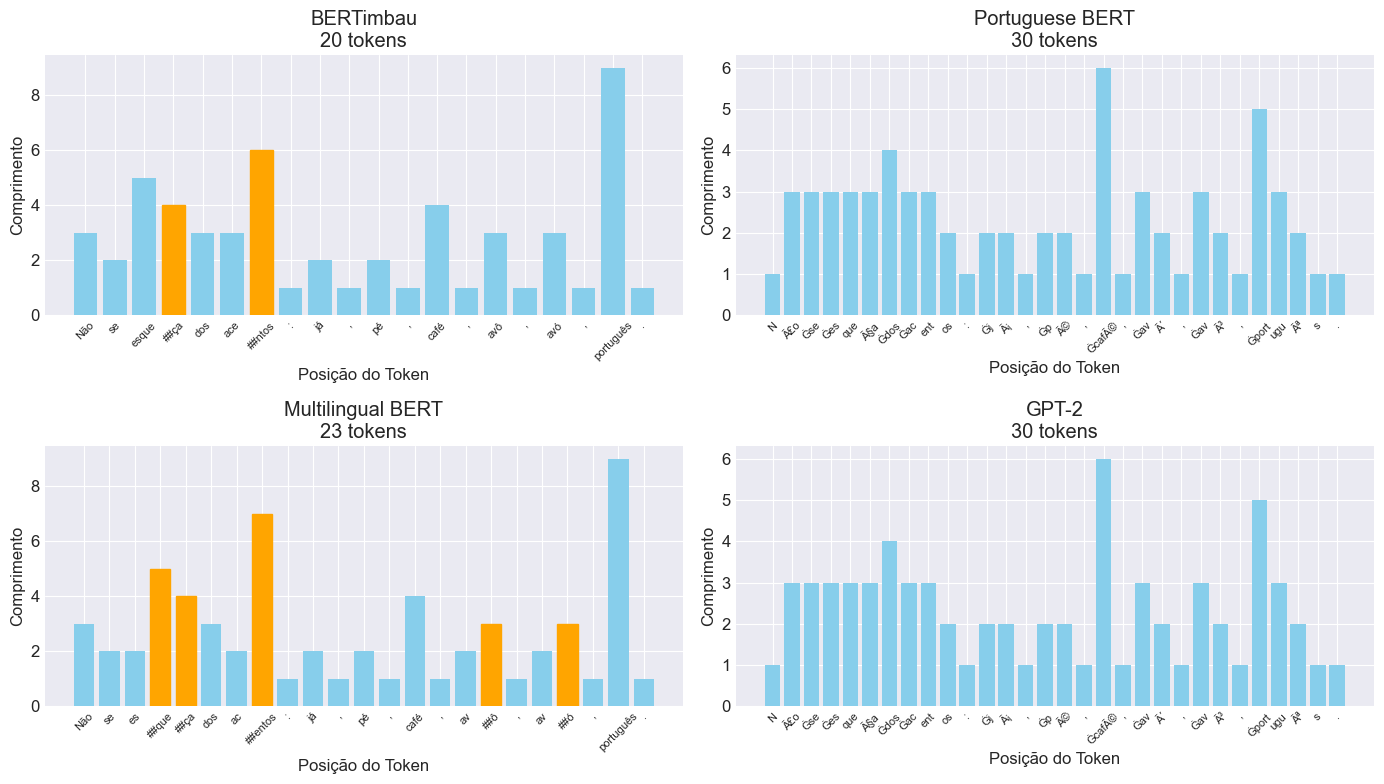


📖 Texto: Contrações comuns: do, da, no, na, dum, numa, pelo, pela.


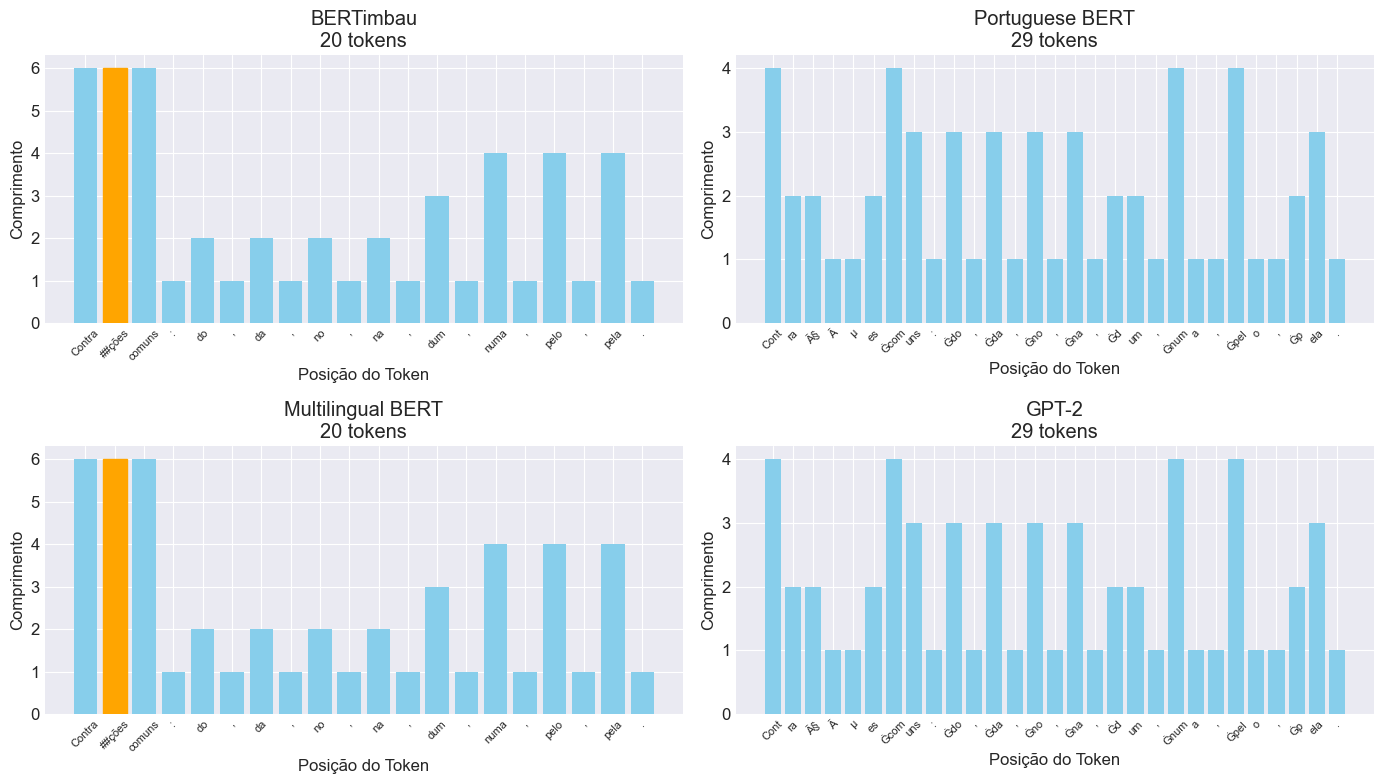


📖 Texto: Palavras compostas: guarda-chuva, beija-flor, segunda-feira.


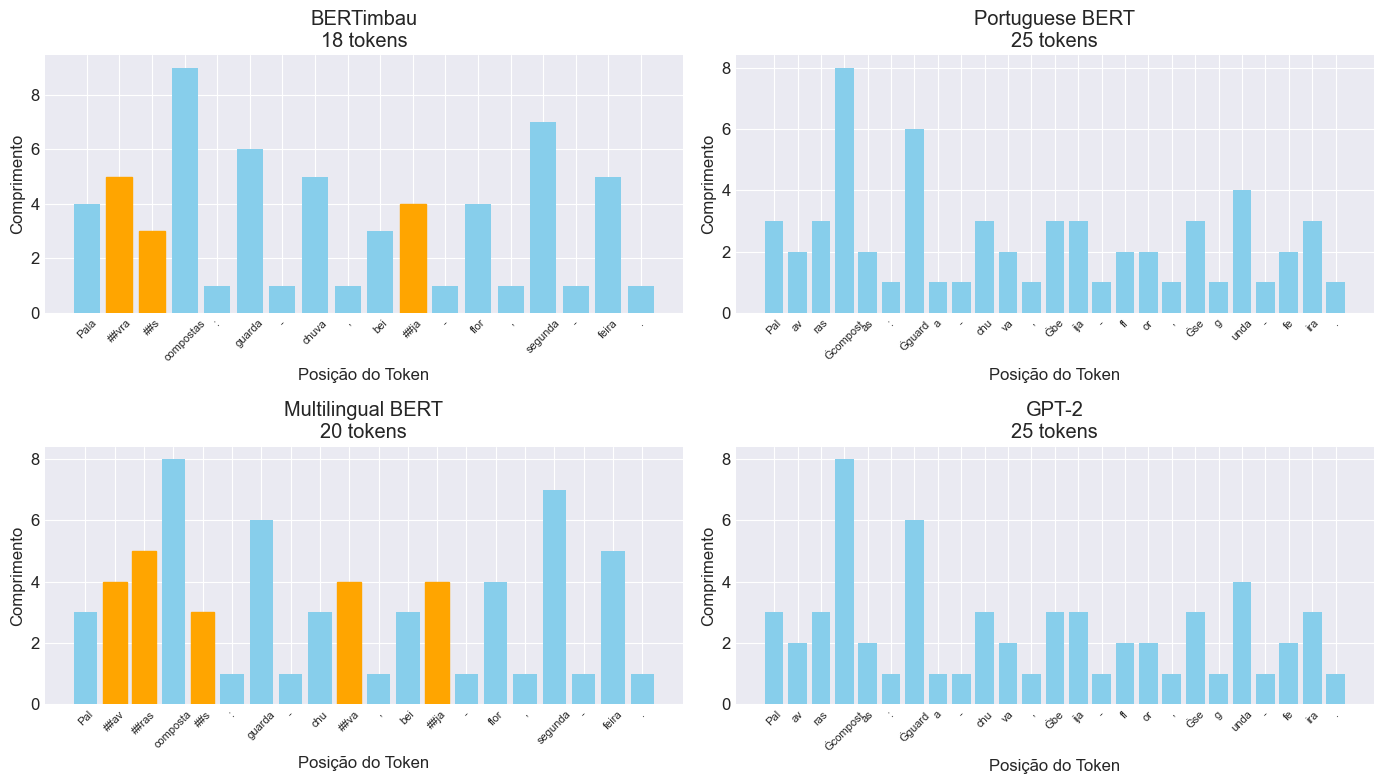


📖 Texto: Termos técnicos: inteligência artificial, machine learning.


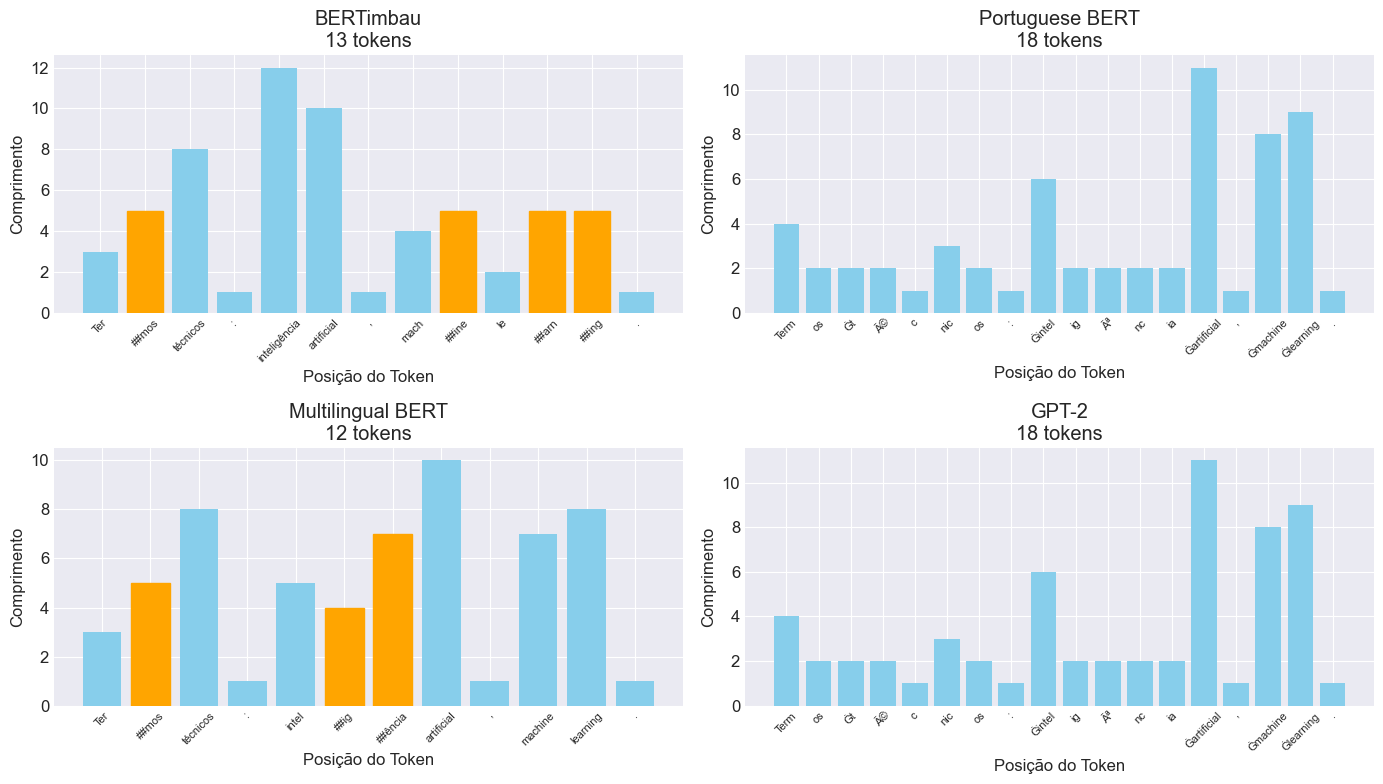

In [7]:
# Análise detalhada de tokenizadores para português
textos_pt = [
    "Não se esqueça dos acentos: já, pé, café, avô, avó, português.",
    "Contrações comuns: do, da, no, na, dum, numa, pelo, pela.",
    "Palavras compostas: guarda-chuva, beija-flor, segunda-feira.",
    "Termos técnicos: inteligência artificial, machine learning."
]

modelos_pt = {
    "BERTimbau": "neuralmind/bert-base-portuguese-cased",
    "Portuguese BERT": "PORTULAN/albertina-ptpt-base",
    "Multilingual BERT": "bert-base-multilingual-cased",
    "GPT-2": "gpt2"  # Para comparação
}

print("🇧🇷 ANÁLISE DE TOKENIZAÇÃO EM PORTUGUÊS")
print("="*60)

for texto in textos_pt:
    print(f"\n📖 Texto: {texto}")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.flatten()
    
    for idx, (nome, modelo) in enumerate(modelos_pt.items()):
        try:
            tokenizer = AutoTokenizer.from_pretrained(modelo)
            tokens = tokenizer.tokenize(texto)
            
            # Gráfico de distribuição de comprimento de tokens
            token_lengths = [len(t) for t in tokens]
            
            axes[idx].bar(range(len(token_lengths)), token_lengths, color='skyblue')
            axes[idx].set_title(f'{nome}\n{len(tokens)} tokens')
            axes[idx].set_xlabel('Posição do Token')
            axes[idx].set_ylabel('Comprimento')
            axes[idx].set_xticks(range(len(tokens)))
            axes[idx].set_xticklabels(tokens, rotation=45, fontsize=8)
            
            # Destacar tokens especiais
            for j, token in enumerate(tokens):
                if token.startswith('##'):
                    axes[idx].get_children()[j].set_color('orange')
                elif token in ['[CLS]', '[SEP]', '[PAD]', '[UNK]']:
                    axes[idx].get_children()[j].set_color('red')
        
        except Exception as e:
            axes[idx].text(0.5, 0.5, f'Erro\n{e}', ha='center', va='center')
            axes[idx].set_title(nome)
    
    plt.tight_layout()
    plt.show()

## 6. Tokenização Jurídica

### Casos Especiais no Direito:
1. **Referências legais**: "Art. 5º, § 3º, inciso IV"
2. **Latinismos**: "habeas corpus", "ex officio"
3. **Siglas**: "STF", "TRT", "TJSP"
4. **Números de processos**: "0001234-12.2012.4.01.3400"

Vamos criar um tokenizador especializado para textos jurídicos.

In [8]:
class TokenizadorJuridico:
    """Tokenizador especializado para textos jurídicos em português"""
    
    def __init__(self):
        self.padroes_especiais = {
            r'art\.?\s*\d+[ºª°]?': 'ARTIGO_NUM',
            r'§\s*\d+[ºª°]?': 'PARAGRAFO_NUM',
            r'inc\.?\s*[IVXLCDM]+': 'INCISO_NUM',
            r'stf|trt|tj\w*': 'TRIBUNAL_SIGLA',
            r'\d{7}-\d{2}\.\d{4}\.\d\.\d{2}\.\d{4}': 'NUMERO_PROCESSO',
            r'habeas\s+corpus|ex\s+officio': 'LATINISMO',
        }
        
    def preprocessar_texto_juridico(self, texto):
        """Pré-processamento específico para textos jurídicos"""
        # Converter para minúsculas mas preservar algumas maiúsculas
        texto = texto.lower()
        
        # Preservar referências a tribunais
        texto = re.sub(r'\b(STF|TRT|TJ\w*)\b', lambda m: m.group().upper(), texto)
        
        # Adicionar espaços em referências legais
        texto = re.sub(r'(art\.?)(\d+)', r'\1 \2', texto)
        texto = re.sub(r'(§)(\d+)', r'\1 \2', texto)
        texto = re.sub(r'(inc\.?)([IVXLCDM]+)', r'\1 \2', texto)
        
        return texto
    
    def analisar_texto_juridico(self, texto):
        """Analisa texto jurídico e identifica padrões"""
        resultados = {
            'texto_original': texto,
            'texto_preprocessado': self.preprocessar_texto_juridico(texto),
            'padroes_encontrados': [],
            'tokens_sugeridos': []
        }
        
        # Identificar padrões especiais
        for padrao, tipo in self.padroes_especiais.items():
            matches = re.finditer(padrao, texto, re.IGNORECASE)
            for match in matches:
                resultados['padroes_encontrados'].append({
                    'tipo': tipo,
                    'texto': match.group(),
                    'posicao': match.span()
                })
        
        return resultados

# Teste com textos jurídicos reais
print("⚖️ TOKENIZAÇÃO JURÍDICA - ANÁLISE ESPECIALIZADA")
print("="*70)

textos_juridicos = [
    "O Art. 5º, § 3º, inciso IV da Constituição Federal foi citado no processo 1234567-89.2012.4.01.0000 do STF.",
    "Conforme decidido pelo TRT da 2ª Região no julgamento do habeas corpus.",
    "O réu foi condenado com base no art. 121 do Código Penal, § 1º.",
    "O STF analisou o recurso extraordinário nº 1234567 no julgamento de ontem."
]

tokenizador_jur = TokenizadorJuridico()

for texto in textos_juridicos:
    print(f"\n📜 Texto jurídico:")
    print(f"   '{texto}'")
    
    analise = tokenizador_jur.analisar_texto_juridico(texto)
    
    print(f"\n🔍 Padrões encontrados:")
    if analise['padroes_encontrados']:
        for padrao in analise['padroes_encontrados']:
            print(f"   - {padrao['tipo']}: '{padrao['texto']}' (posição {padrao['posicao']})")
    else:
        print("   Nenhum padrão jurídico identificado.")
    
    print(f"\n🔄 Texto pré-processado:")
    print(f"   {analise['texto_preprocessado']}")
    print("-"*70)

⚖️ TOKENIZAÇÃO JURÍDICA - ANÁLISE ESPECIALIZADA

📜 Texto jurídico:
   'O Art. 5º, § 3º, inciso IV da Constituição Federal foi citado no processo 1234567-89.2012.4.01.0000 do STF.'

🔍 Padrões encontrados:
   - ARTIGO_NUM: 'Art. 5º' (posição (2, 9))
   - PARAGRAFO_NUM: '§ 3º' (posição (11, 15))
   - INCISO_NUM: 'inci' (posição (17, 21))
   - TRIBUNAL_SIGLA: 'STF' (posição (103, 106))
   - NUMERO_PROCESSO: '1234567-89.2012.4.01.0000' (posição (74, 99))

🔄 Texto pré-processado:
   o art. 5º, § 3º, inciso iv da constituição federal foi citado no processo 1234567-89.2012.4.01.0000 do stf.
----------------------------------------------------------------------

📜 Texto jurídico:
   'Conforme decidido pelo TRT da 2ª Região no julgamento do habeas corpus.'

🔍 Padrões encontrados:
   - TRIBUNAL_SIGLA: 'TRT' (posição (23, 26))
   - LATINISMO: 'habeas corpus' (posição (57, 70))

🔄 Texto pré-processado:
   conforme decidido pelo trt da 2ª região no julgamento do habeas corpus.
----------------------

### Tokenização com Legal-BERT
Legal-BERT é um BERT especializado em textos jurídicos. Vamos testá-lo:

In [9]:
# Testando Legal-BERT (modelo em inglês, mas útil para conceitos)
try:
    from transformers import AutoTokenizer
    
    print("🔍 Testando Legal-BERT (inglês) para conceitos jurídicos:")
    
    legal_bert_tokenizer = AutoTokenizer.from_pretrained("nlpaueb/legal-bert-base-uncased")
    
    textos_juridicos_en = [
        "The defendant filed a habeas corpus petition.",
        "Article 1, Section 8 of the Constitution.",
        "The Supreme Court granted certiorari.",
        "The plaintiff appealed the district court's decision."
    ]
    
    for texto in textos_juridicos_en:
        tokens = legal_bert_tokenizer.tokenize(texto)
        print(f"\n📝 Texto: {texto}")
        print(f"   Tokens: {tokens}")
        print(f"   Número de tokens: {len(tokens)}")
        
except Exception as e:
    print(f"⚠️  Não foi possível carregar Legal-BERT: {e}")
    print("   Tentando carregar BERTimbau para comparação...")
    
    bertimbau_tokenizer = AutoTokenizer.from_pretrained("neuralmind/bert-base-portuguese-cased")
    
    texto_jur_pt = "O réu apresentou pedido de habeas corpus."
    tokens = bertimbau_tokenizer.tokenize(texto_jur_pt)
    print(f"\n📝 Texto (PT): {texto_jur_pt}")
    print(f"   Tokens: {tokens}")

🔍 Testando Legal-BERT (inglês) para conceitos jurídicos:

📝 Texto: The defendant filed a habeas corpus petition.
   Tokens: ['the', 'defendant', 'filed', 'a', 'habeas', 'corpus', 'petition', '.']
   Número de tokens: 8

📝 Texto: Article 1, Section 8 of the Constitution.
   Tokens: ['article', '1', ',', 'section', '8', 'of', 'the', 'constitution', '.']
   Número de tokens: 9

📝 Texto: The Supreme Court granted certiorari.
   Tokens: ['the', 'supreme', 'court', 'granted', 'certi', '##orari', '.']
   Número de tokens: 7

📝 Texto: The plaintiff appealed the district court's decision.
   Tokens: ['the', 'plaintiff', 'appealed', 'the', 'district', 'court', "'", 's', 'decision', '.']
   Número de tokens: 10


## 7. Exercícios Práticos

### Exercício 1: Analise a CLT

In [10]:
# Exercício 1: Tokenizar trechos da CLT
textos_clt = [
    "Art. 1º Esta Consolidação estatui as normas reguladoras das relações individuais e coletivas de trabalho, nela previstas.",
    "Art. 2º Considera-se empregador a empresa, individual ou coletiva, que, assumindo os riscos da atividade econômica, admite, assalaria e dirige a prestação pessoal de serviço.",
    "Art. 3º Considera-se empregado toda pessoa física que prestar serviços de natureza não eventual a empregador, sob a dependência deste e mediante salário."
]

print("📚 EXERCÍCIO 1: ANÁLISE DA CLT")
print("="*70)

bertimbau_tokenizer = AutoTokenizer.from_pretrained("neuralmind/bert-base-portuguese-cased")

for i, texto in enumerate(textos_clt, 1):
    print(f"\nArtigo {i}:")
    print(f"Texto: {texto[:80]}...")
    
    tokens = bertimbau_tokenizer.tokenize(texto)
    token_ids = bertimbau_tokenizer.encode(texto)
    
    print(f"Número de tokens: {len(tokens)}")
    print(f"Número de token IDs: {len(token_ids)}")
    
    # Análise estatística
    token_lengths = [len(t) for t in tokens]
    print(f"Comprimento médio dos tokens: {np.mean(token_lengths):.2f}")
    print(f"Tokens mais longos: {sorted([t for t in tokens if len(t) > 10], key=len, reverse=True)[:3]}")
    
    # Tokens especiais
    special_tokens = [t for t in tokens if t.startswith('##') or t in ['[CLS]', '[SEP]']]
    if special_tokens:
        print(f"Tokens especiais encontrados: {special_tokens}")

📚 EXERCÍCIO 1: ANÁLISE DA CLT

Artigo 1:
Texto: Art. 1º Esta Consolidação estatui as normas reguladoras das relações individuais...
Número de tokens: 26
Número de token IDs: 28
Comprimento médio dos tokens: 4.62
Tokens mais longos: ['individuais']
Tokens especiais encontrados: ['##oli', '##dação', '##i', '##doras', '##s', '##s']

Artigo 2:
Texto: Art. 2º Considera-se empregador a empresa, individual ou coletiva, que, assumind...
Número de tokens: 36
Número de token IDs: 38
Comprimento médio dos tokens: 4.36
Tokens mais longos: []
Tokens especiais encontrados: ['##r', '##aria']

Artigo 3:
Texto: Art. 3º Considera-se empregado toda pessoa física que prestar serviços de nature...
Número de tokens: 29
Número de token IDs: 31
Comprimento médio dos tokens: 4.69
Tokens mais longos: ['dependência']
Tokens especiais encontrados: ['##r']


### Exercício 2: Crie um Vocabulário Personalizado

In [11]:
# Exercício 2: Vocabulário personalizado para termos jurídicos
class VocabularioJuridico:
    def __init__(self):
        self.vocabulario = {}
        self.termos_juridicos = set()
        
    def extrair_termos_juridicos(self, textos):
        """Extrai termos jurídicos de uma lista de textos"""
        termos_comuns = {
            # Substantivos
            'ação', 'processo', 'recurso', 'sentença', 'decisão', 'acórdão',
            'jurisprudência', 'legislação', 'norma', 'lei', 'decreto',
            'constituição', 'código', 'penal', 'civil', 'trabalho',
            
            # Verbos
            'ajuizar', 'recorrer', 'decisão', 'julgar', 'condenar', 'absolver',
            
            # Latinismos
            'habeas corpus', 'ex officio', 'prima facie', 'stare decisis',
            
            # Siglas
            'STF', 'STJ', 'TST', 'TRT', 'TJ'
        }
        
        # Adiciona termos comuns
        self.termos_juridicos.update(termos_comuns)
        
        # Extrai termos dos textos
        for texto in textos:
            palavras = texto.lower().split()
            for palavra in palavras:
                if len(palavra) > 5:  # Filtra palavras muito curtas
                    self.termos_juridicos.add(palavra)
        
        return self.termos_juridicos
    
    def criar_vocabulario_numerico(self):
        """Cria vocabulário com IDs numéricos"""
        # Tokens especiais
        self.vocabulario = {
            '[PAD]': 0,
            '[UNK]': 1,
            '[CLS]': 2,
            '[SEP]': 3,
            '[MASK]': 4
        }
        
        # Adiciona termos jurídicos
        next_id = 5
        for termo in sorted(self.termos_juridicos):
            if termo not in self.vocabulario:
                self.vocabulario[termo] = next_id
                next_id += 1
        
        return self.vocabulario
    
    def tokenizar_com_vocabulario(self, texto):
        """Tokeniza texto usando vocabulário personalizado"""
        palavras = texto.lower().split()
        tokens = []
        
        for palavra in palavras:
            if palavra in self.vocabulario:
                tokens.append(self.vocabulario[palavra])
            else:
                # Tenta decompor a palavra
                for i in range(len(palavra), 0, -1):
                    prefixo = palavra[:i]
                    if prefixo in self.vocabulario:
                        tokens.append(self.vocabulario[prefixo])
                        # Restante da palavra vai para UNK
                        if palavra[i:]:
                            tokens.append(self.vocabulario['[UNK]'])
                        break
                else:
                    tokens.append(self.vocabulario['[UNK]'])
        
        return tokens

# Teste do vocabulário personalizado
print("\n📚 EXERCÍCIO 2: VOCABULÁRIO JURÍDICO PERSONALIZADO")
print("="*70)

vocab_jur = VocabularioJuridico()
termos = vocab_jur.extrair_termos_juridicos(textos_clt + textos_juridicos)

print(f"Termos jurídicos extraídos ({len(termos)}):")
print(sorted(list(termos))[:20], "...")

vocabulario = vocab_jur.criar_vocabulario_numerico()
print(f"\nVocabulário criado com {len(vocabulario)} tokens")

# Teste de tokenização
texto_teste = "O processo judicial foi julgado pelo STF com base na Constituição"
tokens = vocab_jur.tokenizar_com_vocabulario(texto_teste)

print(f"\nTexto: {texto_teste}")
print(f"Tokens IDs: {tokens}")
print(f"Tokens correspondentes:")
for token_id in tokens:
    for termo, id_ in vocabulario.items():
        if id_ == token_id:
            print(f"  {token_id}: {termo}")
            break


📚 EXERCÍCIO 2: VOCABULÁRIO JURÍDICO PERSONALIZADO
Termos jurídicos extraídos (81):
['1234567', '1234567-89.2012.4.01.0000', 'STF', 'STJ', 'TJ', 'TRT', 'TST', 'absolver', 'acórdão', 'admite,', 'ajuizar', 'analisou', 'assalaria', 'assumindo', 'atividade', 'ação', 'citado', 'civil', 'coletiva,', 'coletivas'] ...

Vocabulário criado com 86 tokens

Texto: O processo judicial foi julgado pelo STF com base na Constituição
Tokens IDs: [1, 72, 1, 1, 1, 1, 1, 1, 1, 1, 30]
Tokens correspondentes:
  1: [UNK]
  72: processo
  1: [UNK]
  1: [UNK]
  1: [UNK]
  1: [UNK]
  1: [UNK]
  1: [UNK]
  1: [UNK]
  1: [UNK]
  30: constituição


### Exercício 3: Otimização para sua GPU
Com 2GB de VRAM, precisamos ser eficientes:

💡 EXERCÍCIO 3: OTIMIZAÇÃO PARA GPU 2GB

📊 Análise de Memória para Textos Jurídicos:
----------------------------------------------------------------------

Texto: Artigo único.
  Tokens: 6
  Memória estimada: 0.02 MB

Texto: Art. 1º da Constituição Federal.
  Tokens: 9
  Memória estimada: 0.03 MB

Texto: O artigo 5º da Constituição Federal garante direit...
  Tokens: 12
  Memória estimada: 0.04 MB

Texto: Art. 1º Esta Consolidação estatui as normas regula...
  Tokens: 28
  Memória estimada: 0.08 MB

Texto: Art. 1º Esta Consolidação estatui as normas regula...
  Tokens: 93
  Memória estimada: 0.27 MB


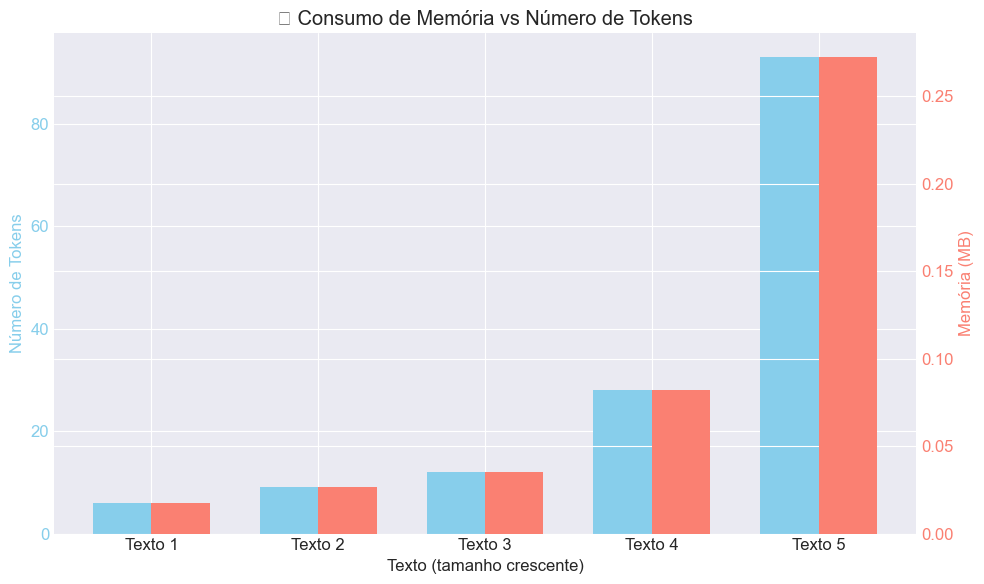


🎯 RECOMENDAÇÕES para sua GPU (2GB):
1. Limite máximo de tokens por documento: ~512
2. Use chunking para documentos longos
3. Prefira modelos com hidden_size menor
4. Use dtype float16 em vez de float32
5. Para documentos muito longos, use RAG (Retrieval Augmented Generation)


In [12]:
# Exercício 3: Otimização para GPU com memória limitada
print("💡 EXERCÍCIO 3: OTIMIZAÇÃO PARA GPU 2GB")
print("="*70)

def calcular_memoria_texto(texto, tokenizer, dtype_bytes=2):
    """Calcula memória necessária para processar texto"""
    tokens = tokenizer.encode(texto)
    num_tokens = len(tokens)
    
    # Estimativa: cada token precisa de embedding + atenção
    # Simplificação: 2 * seq_length * hidden_size * bytes_per_param
    hidden_size = 768  # Típico para BERT-base
    memoria_estimada = num_tokens * hidden_size * dtype_bytes * 2  # Input + gradientes
    
    return {
        'texto': texto[:50] + "..." if len(texto) > 50 else texto,
        'num_tokens': num_tokens,
        'memoria_estimada_MB': memoria_estimada / (1024 * 1024),
        'seq_length': num_tokens
    }

# Testar com diferentes tamanhos de texto
bert_tokenizer = AutoTokenizer.from_pretrained("neuralmind/bert-base-portuguese-cased")

textos_teste_memoria = [
    "Artigo único.",
    "Art. 1º da Constituição Federal.",
    "O artigo 5º da Constituição Federal garante direitos fundamentais.",
    textos_clt[0],  # Artigo completo
    "\n".join(textos_clt)  # Vários artigos
]

print("\n📊 Análise de Memória para Textos Jurídicos:")
print("-"*70)

resultados = []
for texto in textos_teste_memoria:
    resultado = calcular_memoria_texto(texto, bert_tokenizer)
    resultados.append(resultado)
    
    print(f"\nTexto: {resultado['texto']}")
    print(f"  Tokens: {resultado['num_tokens']}")
    print(f"  Memória estimada: {resultado['memoria_estimada_MB']:.2f} MB")

# Gráfico comparativo
df_memoria = pd.DataFrame(resultados)
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(df_memoria))
width = 0.35

ax.bar(x, df_memoria['num_tokens'], width, label='Número de Tokens', color='skyblue')
ax.set_xlabel('Texto (tamanho crescente)')
ax.set_ylabel('Número de Tokens', color='skyblue')
ax.tick_params(axis='y', labelcolor='skyblue')

ax2 = ax.twinx()
ax2.bar([i + width for i in x], df_memoria['memoria_estimada_MB'], width, 
        label='Memória Estimada (MB)', color='salmon')
ax2.set_ylabel('Memória (MB)', color='salmon')
ax2.tick_params(axis='y', labelcolor='salmon')

ax.set_xticks([i + width/2 for i in x])
ax.set_xticklabels([f"Texto {i+1}" for i in x])

ax.set_title('📈 Consumo de Memória vs Número de Tokens')
fig.tight_layout()
plt.show()

print("\n🎯 RECOMENDAÇÕES para sua GPU (2GB):")
print("1. Limite máximo de tokens por documento: ~512")
print("2. Use chunking para documentos longos")
print("3. Prefira modelos com hidden_size menor")
print("4. Use dtype float16 em vez de float32")
print("5. Para documentos muito longos, use RAG (Retrieval Augmented Generation)")


## 8. Conclusões e Próximos Passos

### ✅ O que aprendemos:
1. **Por que tokenizar** - Computadores processam números, não texto
2. **Algoritmos principais** - BPE, WordPiece, SentencePiece
3. **Tokenização em português** - Desafios específicos
4. **Tokenização jurídica** - Casos especiais e tratamentos
5. **Otimização para GPU limitada** - Estratégias práticas